     z (Å) |  V(z) (eV)
-------------------------
    -250.0 |     0.7050
    -240.0 |     0.7384
    -230.0 |     0.7718
    -220.0 |     0.8052
    -210.0 |     0.8386
    -200.0 |     0.8720
    -190.0 |     0.9054
    -180.0 |     0.9388
    -170.0 |     0.9722
    -160.0 |     1.0056
    -150.0 |     1.0390
    -140.0 |     1.0724
    -130.0 |     1.1058
    -120.0 |     1.1392
    -110.0 |     1.1726
    -100.0 |     1.2060
     -90.0 |     1.2394
     -80.0 |     1.2728
     -70.0 |     1.3062
     -60.0 |     1.3396
     -50.0 |     1.3730
     -40.0 |     1.4064
     -30.0 |     1.4398
     -20.0 |     1.4732
     -10.0 |     1.5066
       0.0 |    -0.0000
      10.0 |    -0.3900
      20.0 |    -0.7800
      30.0 |    -1.1700
      40.0 |    -1.5600
      50.0 |    -1.9500
      60.0 |    -2.3400
      70.0 |    -2.7300
      80.0 |    -3.1200
      90.0 |    -3.5100
     100.0 |    -3.9000
     110.0 |    -2.3266
     120.0 |    -2.2932
     130.0 |    -2.2598
     140.0 |  

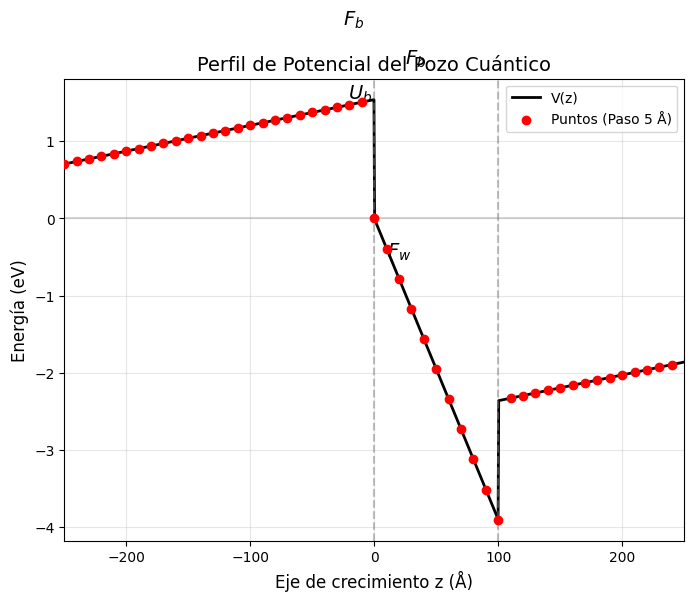

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de Parámetros
# ==========================================
lw = 100.0       # Ancho del pozo en Å
Vb = 1.54      # Discontinuidad de la banda (offset) en eV

# Campos eléctricos en MV/cm
Fw_MVcm = -3.90 
Fb_MVcm = 0.334 # Calculado para compensar el pozo asumiendo lb = 40 Å

# Conversión a eV/Å (1 MV/cm = 0.01 eV/Å)
Fw = Fw_MVcm * 0.01
Fb = Fb_MVcm * 0.01

# ==========================================
# 2. Función del Potencial V(z)
# ==========================================
def V_potential(z):
    """
    Evalúa el potencial V(z) dado un valor de z en Angstroms.
    """
    if z < 0:
        # Región de la barrera izquierda
        return Fb * z + Vb
    elif 0 <= z <= lw:
        # Región del pozo
        return Fw * z
    else:
        # Región de la barrera derecha (Ecuación corregida)
        return Fb * (z - lw) + Fw * lw + Vb

# Vectorizamos la función para poder pasarle arrays de numpy
V_vec = np.vectorize(V_potential)

# ==========================================
# 3. Generación de Datos (Pasos de 5 Å)
# ==========================================
# Generamos z desde -40 hasta 40. Sumamos 1 al límite superior para incluir el 40.
z_puntos = np.arange(-250, 250, 10) 
V_puntos = V_vec(z_puntos)

# Imprimimos los valores calculados en consola para verificación
print(f"{'z (Å)':>10} | {'V(z) (eV)':>10}")
print("-" * 25)
for z_val, v_val in zip(z_puntos, V_puntos):
    print(f"{z_val:10.1f} | {v_val:10.4f}")

# ==========================================
# 4. Gráfica de la Estructura de Bandas
# ==========================================
# Para que las líneas verticales de las interfaces se dibujen perfectamente rectas,
# creamos un vector z continuo (alta resolución)
z_continuo = np.linspace(-250, 250, 1000)
V_continuo = V_vec(z_continuo)

plt.figure(figsize=(8, 6))

# Dibujamos la línea continua del potencial
plt.plot(z_continuo, V_continuo, color='black', linewidth=2, label='V(z)')

# Superponemos los puntos discretos cada 5 Å que solicitaste
plt.scatter(z_puntos, V_puntos, color='red', zorder=5, label='Puntos (Paso 5 Å)')

# Detalles estéticos de la gráfica
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=lw, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Etiquetas como en tu imagen
plt.text(-25, 2.5, r'$F_b$', fontsize=14)
plt.text(10, -0.5, r'$F_w$', fontsize=14)
plt.text(25, 2.0, r'$F_b$', fontsize=14)
plt.text(-2, Vb, r'$U_b$', fontsize=14, ha='right')

plt.xlim(-250, 250)
plt.xlabel('Eje de crecimiento z (Å)', fontsize=12)
plt.ylabel('Energía (eV)', fontsize=12)
plt.title('Perfil de Potencial del Pozo Cuántico', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

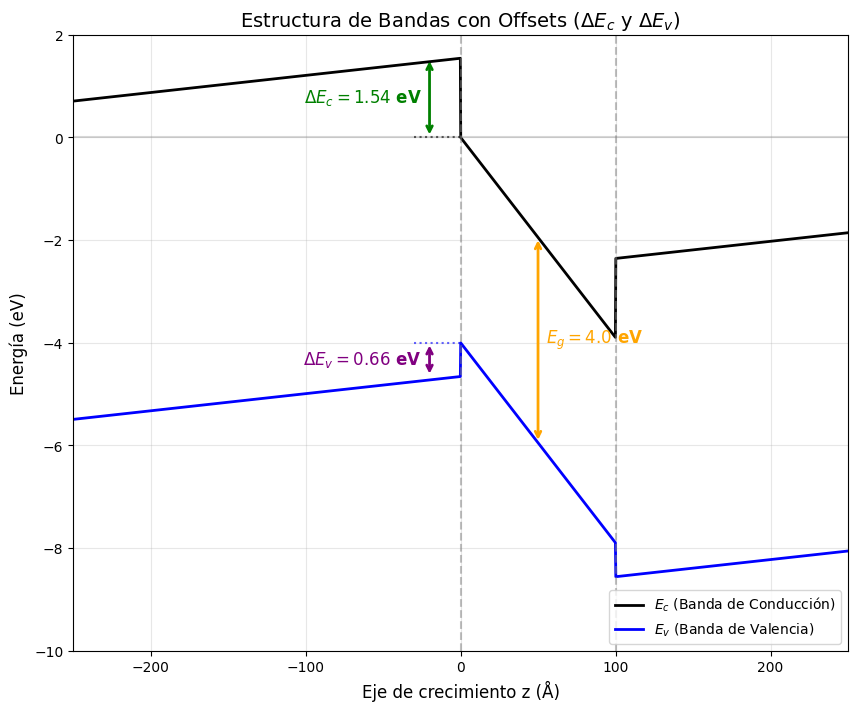

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Parámetros

lw = 100.0       
Vb = 1.54       
Fw = -3.90 * 0.01 
Fb = 0.334 * 0.01 

# Bandgaps 
Eg_pozo = 4.0    
Eg_barrera = 6.2 

def E_conduccion(z):
    if z < 0:
        return Fb * z + Vb
    elif 0 <= z <= lw:
        return Fw * z
    else:
        return Fb * (z - lw) + Fw * lw + Vb

def Bandgap(z):
    if 0 <= z <= lw:
        return Eg_pozo
    else:
        return Eg_barrera

def E_valencia(z):
    return E_conduccion(z) - Bandgap(z)

Ec_vec = np.vectorize(E_conduccion)
Ev_vec = np.vectorize(E_valencia)

z_continuo = np.linspace(-250, 250, 2000)
Ec_continuo = Ec_vec(z_continuo)
Ev_continuo = Ev_vec(z_continuo)

plt.figure(figsize=(10, 8))

plt.plot(z_continuo, Ec_continuo, color='black', linewidth=2, label='$E_c$ (Banda de Conducción)')
plt.plot(z_continuo, Ev_continuo, color='blue', linewidth=2, label='$E_v$ (Banda de Valencia)')

plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=lw, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Offset de Conducción 
plt.hlines(y=0, xmin=-30, xmax=0, color='black', linestyle=':', alpha=0.6)
plt.annotate('', xy=(-20, 0), xytext=(-20, Vb),
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))
plt.text(-25, Vb/2, r'$\Delta E_c = 1.54$ eV', color='green', fontsize=12, fontweight='bold', ha='right', va='center')

# Offset de Valencia
Ev_barrera_0 = Vb - Eg_barrera  
Ev_pozo_0 = 0 - Eg_pozo         
delta_Ev = Ev_pozo_0 - Ev_barrera_0

plt.hlines(y=Ev_pozo_0, xmin=-30, xmax=0, color='blue', linestyle=':', alpha=0.6)
plt.annotate('', xy=(-20, Ev_barrera_0), xytext=(-20, Ev_pozo_0),
             arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
plt.text(-25, (Ev_barrera_0 + Ev_pozo_0)/2, f'$\\Delta E_v = {delta_Ev:.2f}$ eV', color='purple', fontsize=12, fontweight='bold', ha='right', va='center')

centro_pozo = lw / 2
Ec_centro = Fw * centro_pozo
plt.annotate('', xy=(centro_pozo, Ec_centro), xytext=(centro_pozo, Ec_centro - Eg_pozo),
             arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
plt.text(centro_pozo + 5, Ec_centro - Eg_pozo/2, f'$E_g = {Eg_pozo}$ eV', color='orange', fontsize=12, fontweight='bold', ha='left', va='center')

plt.xlim(-250, 250) 
plt.ylim(-10, 2) 
plt.xlabel('Eje de crecimiento z (Å)', fontsize=12)
plt.ylabel('Energía (eV)', fontsize=12)
plt.title('Estructura de Bandas con Offsets ($\Delta E_c$ y $\Delta E_v$)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

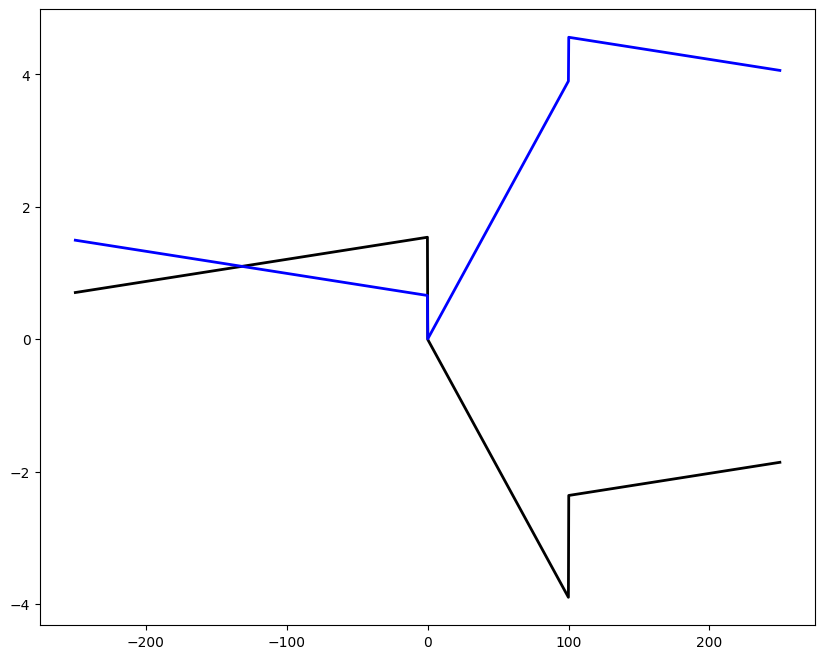

In [7]:
#Parámetros

lw = 100.0       
Vb = 1.54       
Fw = -3.90 * 0.01 
Fb = 0.334 * 0.01 

# Bandgaps 
Eg_pozo = 4.0    
Eg_barrera = 6.2 

def E_conduccion(z):
    if z < 0:
        return Fb * z + Vb
    elif 0 <= z <= lw:
        return Fw * z
    else:
        return Fb * (z - lw) + Fw * lw + Vb

def Bandgap(z):
    if 0 <= z <= lw:
        return Eg_pozo
    else:
        return Eg_barrera

def E_valencia(z):
    return E_conduccion(z) - Bandgap(z)

Ec_vec = np.vectorize(E_conduccion)
Ev_vec = np.vectorize(E_valencia)

z_continuo = np.linspace(-250, 250, 2000)
Ec_continuo = Ec_vec(z_continuo)
Ev_continuo = Ev_vec(z_continuo)


plt.figure(figsize=(10, 8))

plt.plot(z_continuo, Ec_continuo, color='black', linewidth=2, label='$E_c$ (Banda de Conducción)')
plt.plot(z_continuo, - (Ev_continuo +4), color='blue', linewidth=2, label='$E_v$ (Banda de Valencia)')